# Tasks
1. 塩の削除
2. 重複の削除
3. chemical properties
4. クラスタリング

In [1]:
# Load SDF, remove salts (keep largest fragment) and remove duplicates.
from rdkit import Chem

sdf_path = "./chembl/tyk2.sdf"
out_sdf = "./chembl/tyk2_cleaned.sdf"

# load supplier (some entries may be None if parsing failed)
supplier = Chem.SDMolSupplier(sdf_path)
raw_mols = [m for m in supplier]  # preserves positions, may include None

original_count = len(raw_mols)
valid_mols = [m for m in raw_mols if m is not None]
valid_count = len(valid_mols)

# keep largest fragment (by heavy atom count)
def keep_largest_fragment(mol):
    frags = Chem.GetMolFrags(mol, asMols=True, sanitizeFrags=True)
    if not frags:
        return None
    if len(frags) == 1:
        return frags[0]
    return max(frags, key=lambda m: m.GetNumHeavyAtoms())

salt_removed = []
for m in valid_mols:
    try:
        core = keep_largest_fragment(m)
    except Exception:
        core = None
    if core is not None:
        salt_removed.append(core)

after_salt_count = len(salt_removed)

# deduplicate by canonical isomeric SMILES
seen = set()
cleaned_mols = []
for m in salt_removed:
    try:
        smi = Chem.MolToSmiles(m, isomericSmiles=True, canonical=True)
    except Exception:
        # fallback: try sanitizing then get SMILES
        try:
            Chem.SanitizeMol(m)
            smi = Chem.MolToSmiles(m, isomericSmiles=True, canonical=True)
        except Exception:
            continue
    if smi not in seen:
        seen.add(smi)
        cleaned_mols.append(m)

after_dedupe_count = len(cleaned_mols)

# write cleaned molecules
writer = Chem.SDWriter(out_sdf)
for m in cleaned_mols:
    writer.write(m)
writer.close()

# expose cleaned list for further cells
print(f"original entries: {original_count}")
print(f"valid molecules parsed: {valid_count}")
print(f"after salt removal: {after_salt_count}")
print(f"after deduplication: {after_dedupe_count}")

original entries: 2348
valid molecules parsed: 2348
after salt removal: 2348
after deduplication: 1840


In [3]:
import pandas as pd
from rdkit.Chem import PandasTools, Descriptors, rdMolDescriptors

# out_sdf は前セルで作成済み（./chembl/tyk2_cleaned.sdf）
# SD ファイルから DataFrame に読み込む（ROMol カラムに RDKit Mol を格納）
df = PandasTools.LoadSDF(out_sdf, molColName="ROMol", smilesName="smiles", includeFingerprints=False)

# 安全に記述子を計算
df["MolWt"] = df["ROMol"].apply(lambda m: Descriptors.MolWt(m) if m is not None else None)
df["TPSA"] = df["ROMol"].apply(lambda m: rdMolDescriptors.CalcTPSA(m) if m is not None else None)
df["NumHDonors"] = df["ROMol"].apply(lambda m: Descriptors.NumHDonors(m) if m is not None else None)
df["NumHAcceptors"] = df["ROMol"].apply(lambda m: Descriptors.NumHAcceptors(m) if m is not None else None)
df["NumRotatableBonds"] = df["ROMol"].apply(lambda m: Descriptors.NumRotatableBonds(m) if m is not None else None)
df["NumAtoms"] = df["ROMol"].apply(lambda m: m.GetNumAtoms() if m is not None else None)
df["NumHeavyAtoms"] = df["ROMol"].apply(lambda m: m.GetNumHeavyAtoms() if m is not None else None)

print(f"DataFrame shape: {df.shape}")
df.head()


DataFrame shape: (1840, 31)


,canonical_smiles,document_chembl_id,document_journal,molecule_pref_name,parent_molecule_chembl_id,pchembl_value,target_pref_name,value,Murcko_SMILES,Murcko_generic_SMILES,...,Ct amide,ID,smiles,ROMol,MolWt,NumHDonors,NumHAcceptors,NumRotatableBonds,NumAtoms,NumHeavyAtoms
0,CC(C)(C)c1nc2c3ccc(F)cc3c3c(=O)[nH]ccc3c2[nH]1,CHEMBL1135866,Bioorg Med Chem Lett,None,CHEMBL21156,9.00,Tyrosine-protein kinase TYK2,0.001,O=c1[nH]ccc2c3[nH]cnc3c3ccccc3c12,CC1CCCC2C3CCCC3C3CCCCC3C12,...,0,CHEMBL21156,CC(C)(C)c1nc2c3ccc(F)cc3c3c(=O)[nH]ccc3c2[nH]1,<rdkit.Chem.rdchem.Mol object at 0x165035f50>,309.344,2,2,0,23,23
1,CNc1ncc2cc(-c3cc(C(=O)Nc4cc(C(F)(F)F)ccc4OC4CC...,CHEMBL1149344,J Med Chem,None,CHEMBL386661,5.56,Tyrosine-protein kinase TYK2,2.73,O=C(Nc1ccccc1OC1CCNCC1)c1cccc(-c2ccc3ncncc3c2)c1,CC(CC1CCCCC1CC1CCCCC1)C1CCCC(C2CCC3CCCCC3C2)C1,...,1,CHEMBL386661,CNc1ncc2cc(-c3cc(C(=O)Nc4cc(C(F)(F)F)ccc4OC4CC...,<rdkit.Chem.rdchem.Mol object at 0x179adb610>,549.597,2,6,6,40,40
2,Cc1ccc(C(=O)Nc2cccc(C(F)(F)F)c2)cc1-c1ccc2nc(N...,CHEMBL1149344,J Med Chem,None,CHEMBL215943,5.74,Tyrosine-protein kinase TYK2,1.83,O=C(Nc1ccccc1)c1cccc(-c2ccc3nc(NCCN4CCOCC4)ncc...,CC(CC1CCCCC1)C1CCCC(C2CCC3CC(CCCC4CCCCC4)CCC3C...,...,1,CHEMBL215943,Cc1ccc(C(=O)Nc2cccc(C(F)(F)F)c2)cc1-c1ccc2nc(N...,<rdkit.Chem.rdchem.Mol object at 0x179adb8b0>,535.570,2,6,7,39,39
3,Cc1cccc(C)c1-n1c(=O)c2cnc(Nc3ccc(N4CCN(C)CC4)c...,CHEMBL1143254,J Med Chem,None,CHEMBL410295,5.92,Tyrosine-protein kinase TYK2,1.2,O=c1c2cnc(Nc3ccc(N4CCNCC4)cc3)nc2n2c3ccccc3nc2...,CC1C2CCC(CC3CCC(C4CCCCC4)CC3)CC2C2C3CCCCC3CC2C...,...,0,CHEMBL410295,Cc1cccc(C)c1-n1c(=O)c2cnc(Nc3ccc(N4CCN(C)CC4)c...,<rdkit.Chem.rdchem.Mol object at 0x179adb220>,530.636,1,9,4,40,40
4,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...,CHEMBL1156430,Proc Natl Acad Sci U S A,TAE-684,CHEMBL509032,5.64,Tyrosine-protein kinase TYK2,2.309,c1ccc(Nc2ccnc(Nc3ccc(N4CCC(N5CCNCC5)CC4)cc3)n2...,C1CCC(CC2CCCC(CC3CCC(C4CCC(C5CCCCC5)CC4)CC3)C2...,...,0,CHEMBL509032,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...,<rdkit.Chem.rdchem.Mol object at 0x179adb290>,614.216,2,10,9,42,42


best k (silhouette): 2, score: 0.3725
cluster
0.0    1333
1.0     507
Name: count, dtype: int64

centroids (original scale):
              MolWt        TPSA  NumHDonors  NumHAcceptors  NumRotatableBonds  \
cluster                                                                         
0        371.643134   85.502941    1.911478       5.430608           3.928732   
1        475.114382  122.654517    2.857988       8.256410           7.459566   

         NumHeavyAtoms  
cluster                 
0            26.733683  
1            34.266272  


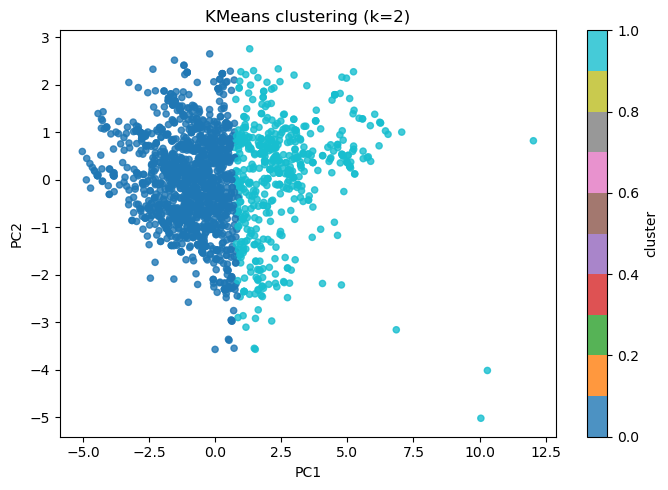

In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import pandas as pd

# クラスタリング（特徴量の標準化、KMeans、シルエットスコアによる k 推定、結果を df に追加して可視化）
import matplotlib.pyplot as plt

# 使用する記述子（既存の df を利用）
features = ["MolWt", "TPSA", "NumHDonors", "NumHAcceptors", "NumRotatableBonds", "NumHeavyAtoms"]

# 欠損があれば除外（今回の df は non-null のはず）
X = df[features].dropna()
idx = X.index
X_vals = X.values

# 標準化
scaler = StandardScaler()
Xs = scaler.fit_transform(X_vals)

# k を 2..10 で評価して最良のシルエットスコアを持つ k を選択
scores = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xs)
    scores[k] = silhouette_score(Xs, labels)

best_k = max(scores, key=scores.get)
print(f"best k (silhouette): {best_k}, score: {scores[best_k]:.4f}")

# 最終モデルを学習して df にクラスタ列を追加
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(Xs)
labels = kmeans.labels_
# 元の df とインデックスを合わせて cluster 列を挿入
df.loc[idx, "cluster"] = labels.astype(int)

print(df["cluster"].value_counts().sort_index())

# クラスタ中心（元スケール）を表示
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=features)
centroids_df.index.name = "cluster"
print("\ncentroids (original scale):")
print(centroids_df)

# 2D 可視化（PCA）
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(Xs)
plt.figure(figsize=(7,5))
scatter = plt.scatter(pcs[:,0], pcs[:,1], c=labels, cmap="tab10", s=20, alpha=0.8)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title(f"KMeans clustering (k={best_k})")
plt.colorbar(scatter, label="cluster")
plt.tight_layout()
plt.show()

In [5]:
from rdkit.Chem import AllChem
from rdkit import DataStructs
import numpy as np

# Morgan fingerprint を計算して KMeans で再クラスタリング（PCA で次元削減）
nBits = 2048
radius = 2

# molecules は既に df['ROMol'] にある前提
mols = df['ROMol'].tolist()

# ビットベクトルを作成
fps = [AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=nBits) for m in mols]

# numpy 配列に変換
arr = np.zeros((len(fps), nBits), dtype=np.uint8)
for i, fp in enumerate(fps):
    DataStructs.ConvertToNumpyArray(fp, arr[i])

# PCA による次元削減（サンプル数やビット数に応じて次元数を決定）
n_components = min(50, arr.shape[0] - 1, arr.shape[1])
pca_fp = PCA(n_components=n_components, random_state=42)
X_pca = pca_fp.fit_transform(arr)

# 標準化
scaler_fp = StandardScaler()
Xs_fp = scaler_fp.fit_transform(X_pca)

# k を 2..10 で評価し、シルエットスコアで最良 k を選択
scores_fp = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(Xs_fp)
    scores_fp[k] = silhouette_score(Xs_fp, labels_k)

best_k_fp = max(scores_fp, key=scores_fp.get)
print(f"best k (fingerprint PCA, silhouette): {best_k_fp}, score: {scores_fp[best_k_fp]:.4f}")

# 最終モデルを学習して df に列を追加
kmeans_fp = KMeans(n_clusters=best_k_fp, random_state=42, n_init=10).fit(Xs_fp)
labels_fp = kmeans_fp.labels_
df['cluster_fp'] = labels_fp

print(df['cluster_fp'].value_counts().sort_index())

# 各クラスタから代表的な例をいくつか表示
for c in sorted(df['cluster_fp'].unique()):
    examples = df.loc[df['cluster_fp'] == c, 'smiles'].head(3).tolist()
    print(f"cluster {c}: {len(df[df['cluster_fp'] == c])} members, examples: {examples}")

[22:16:58] DEPRECATION WARNING: please use MorganGenerator
[22:16:58] DEPRECATION WARNING: please use MorganGenerator
[22:16:58] DEPRECATION WARNING: please use MorganGenerator
[22:16:58] DEPRECATION WARNING: please use MorganGenerator
[22:16:58] DEPRECATION WARNING: please use MorganGenerator
[22:16:58] DEPRECATION WARNING: please use MorganGenerator
[22:16:58] DEPRECATION WARNING: please use MorganGenerator
[22:16:58] DEPRECATION WARNING: please use MorganGenerator
[22:16:58] DEPRECATION WARNING: please use MorganGenerator
[22:16:58] DEPRECATION WARNING: please use MorganGenerator
[22:16:58] DEPRECATION WARNING: please use MorganGenerator
[22:16:58] DEPRECATION WARNING: please use MorganGenerator
[22:16:58] DEPRECATION WARNING: please use MorganGenerator
[22:16:58] DEPRECATION WARNING: please use MorganGenerator
[22:16:58] DEPRECATION WARNING: please use MorganGenerator
[22:16:58] DEPRECATION WARNING: please use MorganGenerator
[22:16:58] DEPRECATION WARNING: please use MorganGenerat

best k (fingerprint PCA, silhouette): 10, score: 0.0785
cluster_fp
0      50
1      55
2      60
3    1296
4      23
5      87
6      47
7     123
8      75
9      24
Name: count, dtype: int64
cluster 0: 50 members, examples: ['Cc1cnc(Nc2ccc3c(c2)CN(C(=O)/C=C/CN(C)C)CC3)nc1-c1cnn(C(C)C)c1', 'Cc1ccc(C(=O)/C=C/C(=O)N2CCc3ccc(Nc4ncc(C)c(-c5cnn(C(C)C)c5)n4)cc3C2)cc1', 'Cc1cnc(Nc2ccc3c(c2)CN(C(=O)/C=C/C(=O)c2ccccc2)CC3)nc1-c1cnn(C(C)C)c1']
cluster 1: 55 members, examples: ['CN1C/C=C/CCn2ccc3ccc(cc32)-c2ccnc(n2)Nc2cccc(c2)C1', 'C1=C/Cn2ccc3ccc(cc32)-c2ccnc(n2)Nc2cccc(c2)COC/1', 'CN1C/C=C/CCOc2cc(ccn2)-c2ccnc(n2)Nc2cccc(c2)C1']
cluster 2: 60 members, examples: ['NC(=O)c1cnc2[nH]ccc2c1NC1CCN(Cc2ccccc2)CC1', 'CNC(=O)c1cnc2[nH]ccc2c1NC1CCN(Cc2ccccc2)CC1', 'CNC(=O)c1cnc2[nH]ccc2c1NC1CCN(Cc2ccccc2OC)CC1']
cluster 3: 1296 members, examples: ['CC(C)(C)c1nc2c3ccc(F)cc3c3c(=O)[nH]ccc3c2[nH]1', 'CNc1ncc2cc(-c3cc(C(=O)Nc4cc(C(F)(F)F)ccc4OC4CCN(C)CC4)ccc3C)ccc2n1', 'Cc1ccc(C(=O)Nc2cccc(C(F)(F)F)c2)cc1-c1

best k (Tanimoto distance, silhouette): 9, score: 0.1232
cluster_tanimoto
0    127
1     46
2    957
3     64
4     24
5      3
6    617
7      1
8      1
Name: count, dtype: int64
cluster 0: size=127, avg_tanimoto=0.239
cluster 1: size=46, avg_tanimoto=0.268
cluster 2: size=957, avg_tanimoto=0.179
cluster 3: size=64, avg_tanimoto=0.340
cluster 4: size=24, avg_tanimoto=0.202
cluster 5: size=3, avg_tanimoto=0.372
cluster 6: size=617, avg_tanimoto=0.335
cluster 7: size=1, avg_tanimoto=1.000
cluster 8: size=1, avg_tanimoto=1.000


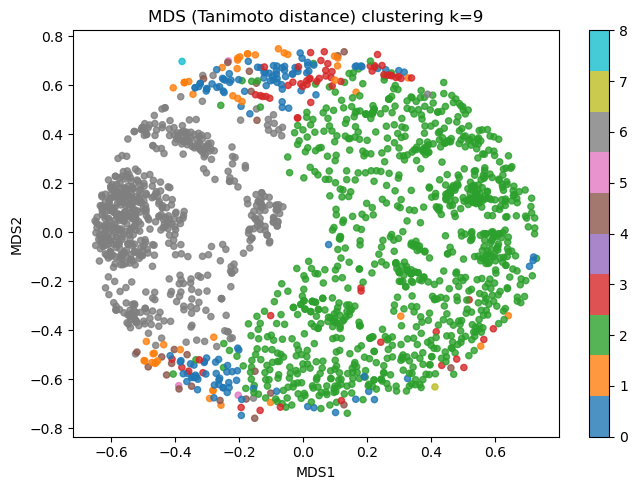

Butina cutoff=0.2: #clusters=1211, largest cluster sizes (top5)=[19, 15, 15, 13, 12]
examples: ['c1cc2c(ncn3nnc([C@H]4CC[C@H](CNCC5CC5)CC4)c23)[nH]1', 'CNc1cc(Nc2cccn(-c3ncccc3F)c2=O)nc2c(C(=O)NC3CC3)cnn12', 'CNC(=O)c1cnc2[nH]ccc2c1N[C@H]1CCN(Cc2ccc(Cl)cc2)[C@@H](C)C1', 'OC1CCN(C[C@H]2CC[C@H](c3nnn4cnc5[nH]ccc5c34)CC2)CC1', 'CC1(C)[C@H](Nc2c(C(N)=O)cnn3cc(-c4ccccc4)cc23)CC[C@]1(C)N']
Butina cutoff=0.25: #clusters=887, largest cluster sizes (top5)=[60, 24, 23, 22, 21]
examples: ['c1cc2c(ncn3nnc([C@H]4CC[C@H](CNCC5CC5)CC4)c23)[nH]1', 'CC1(C)[C@H](Nc2c(C(N)=O)cnn3cc(-c4ccccc4)cc23)CC[C@]1(C)N', '[2H]C([2H])([2H])NC(=O)c1nnc(NC(=O)C2CC2)cc1Nc1cccc(C(=O)Nc2ccc(NC(=O)C3CCCC3)cc2)c1OC', 'CNC(=O)c1cnc2[nH]ccc2c1N[C@@H]1CCN(Cc2ccccc2)[C@@H](C)C1', 'CNc1cc(Nc2cccn(-c3ncccc3F)c2=O)nc2c(C(=O)N[C@@H]3CC[C@H]3OC)cnn12']
Butina cutoff=0.3: #clusters=663, largest cluster sizes (top5)=[108, 38, 35, 34, 28]
examples: ['c1cc2c(ncn3nnc([C@H]4CC[C@H](CNCC5CC5)CC4)c23)[nH]1', '[2H]C([2H])([2H])NC(=O)c1nnc(N

In [7]:
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.manifold import MDS
import numpy as np
import matplotlib.pyplot as plt

# fps should already be defined in previous cell (Morgan bit vectors)
n = len(fps)
if n < 2:
    print('Not enough molecules for clustering')
else:
    # build full similarity matrix using BulkTanimotoSimilarity for speed
    sim = np.eye(n, dtype=float)
    for i in range(n):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps)
        sim[i, :] = np.array(sims)
    # distance matrix (dissimilarity = 1 - similarity)
    dist = 1.0 - sim

    # Agglomerative clustering on precomputed distance; evaluate k=2..10 by silhouette (precomputed)
    scores_tan = {}
    labels_dict = {}
    for k in range(2, min(11, n)):
        # use metric='precomputed' for newer sklearn; fall back to affinity for older versions
        try:
            ac = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
        except TypeError:
            ac = AgglomerativeClustering(n_clusters=k, affinity='precomputed', linkage='average')
        labels = ac.fit_predict(dist)
        # silhouette with precomputed distances
        try:
            sc = silhouette_score(dist, labels, metric='precomputed')
        except Exception as e:
            sc = float('nan')
        scores_tan[k] = sc
        labels_dict[k] = labels

    best_k_tan = max(scores_tan, key=scores_tan.get)
    print(f"best k (Tanimoto distance, silhouette): {best_k_tan}, score: {scores_tan[best_k_tan]:.4f}")

    # use best labels and add to df
    best_labels = labels_dict[best_k_tan]
    df.loc[:, 'cluster_tanimoto'] = best_labels
    print(df['cluster_tanimoto'].value_counts().sort_index())

    # compute average intra-cluster similarity for each cluster
    for c in sorted(np.unique(best_labels)):
        idxs = np.where(best_labels == c)[0]
        if len(idxs) <= 1:
            avg_sim = 1.0
        else:
            sub = sim[np.ix_(idxs, idxs)]
            # exclude diagonal
            m = len(idxs)
            avg_sim = (sub.sum() - m) / (m * (m - 1))
        print(f"cluster {c}: size={len(idxs)}, avg_tanimoto={avg_sim:.3f}")

    # 2D visualization via MDS on precomputed distance
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    coords = mds.fit_transform(dist)
    plt.figure(figsize=(7,5))
    plt.scatter(coords[:,0], coords[:,1], c=best_labels, cmap='tab10', s=20, alpha=0.8)
    plt.title(f'MDS (Tanimoto distance) clustering k={best_k_tan}')
    plt.xlabel('MDS1'); plt.ylabel('MDS2')
    plt.colorbar(); plt.tight_layout(); plt.show()

    # Butina clustering (distance list in upper-triangular order, isDistData=True)
    def _upper_triangular_dist_list(sim_matrix):
        n = sim_matrix.shape[0]
        dlist = []
        for j in range(1, n):
            for i in range(0, j):
                dlist.append(1.0 - sim_matrix[i, j])
        return dlist

    dist_list = _upper_triangular_dist_list(sim)
    thresholds = [0.2, 0.25, 0.3, 0.35, 0.4]
    for cutoff in thresholds:
        clusters = Butina.ClusterData(dist_list, n, cutoff, isDistData=True)
        sizes = sorted([len(c) for c in clusters], reverse=True)
        print(f"Butina cutoff={cutoff}: #clusters={len(clusters)}, largest cluster sizes (top5)={sizes[:5]}")
        # show examples (first SMILES in each of first 5 clusters)
        reps = []
        for c in clusters[:5]:
            reps.append(df['smiles'].iloc[list(c)[0]])
        print('examples:', reps)

In [8]:
import numpy as np
import pandas as pd
from rdkit import Chem

# target number to select
TARGET = 60

# choose clustering column (preference order)
for col in ('cluster_fp', 'cluster_tanimoto', 'cluster'):
    if col in df.columns:
        cluster_col = col
        break
else:
    raise RuntimeError('No cluster column found (cluster_fp/cluster_tanimoto/cluster)')

clust_series = df[cluster_col].dropna().astype(int)
counts = clust_series.value_counts().sort_index()  # index = cluster id
total = counts.sum()

if total == 0:
    raise RuntimeError('No members in clusters')

# proportional raw allocation
raw = counts / total * TARGET
alloc = np.floor(raw).astype(int).values  # initial floor allocation aligned with counts.index

# ensure at least 1 for non-empty clusters when feasible
nonzero_idx = np.where(counts.values > 0)[0]
if len(nonzero_idx) <= TARGET:
    alloc[nonzero_idx] = np.maximum(alloc[nonzero_idx], 1)

allocated = alloc.sum()
fractions = (raw - np.floor(raw)).values
cap = counts.values.copy()  # cannot select more than cluster size

# distribute remainder using fractional parts, respecting caps
i_order = np.argsort(-fractions)  # indices sorted by descending fractional part
i = 0
while allocated < TARGET and i < len(i_order):
    idx = i_order[i]
    if alloc[idx] < cap[idx]:
        alloc[idx] += 1
        allocated += 1
    else:
        # cannot add to this cluster, move on
        pass
    i += 1
    if i == len(i_order) and allocated < TARGET:
        # second pass: fill any clusters with remaining capacity
        for j in range(len(alloc)):
            if allocated >= TARGET:
                break
            if alloc[j] < cap[j]:
                alloc[j] += 1
                allocated += 1

# if we overshot (rare), reduce from clusters with smallest fractional parts
if allocated > TARGET:
    over = allocated - TARGET
    dec_order = np.argsort(fractions)  # ascending fractional part
    k = 0
    while over > 0 and k < len(dec_order):
        idx = dec_order[k]
        if alloc[idx] > 0:
            alloc[idx] -= 1
            over -= 1
        k += 1

# final sanity: do not exceed cluster sizes
alloc = np.minimum(alloc, cap)

# build selection
selected_rows = []
cluster_ids = counts.index.to_list()
for i, cid in enumerate(cluster_ids):
    n_pick = int(alloc[i])
    members = df.loc[df[cluster_col].astype(int) == int(cid)]
    if n_pick <= 0 or len(members) == 0:
        continue
    n_pick = min(n_pick, len(members))
    picked = members.sample(n=n_pick, random_state=42)
    selected_rows.append(picked)

if selected_rows:
    selected_df = pd.concat(selected_rows, ignore_index=True)
else:
    selected_df = pd.DataFrame(columns=df.columns)

print(f"Requested TARGET={TARGET}, obtained {len(selected_df)} selected compounds")
alloc_df = pd.DataFrame({'cluster': cluster_ids, 'cluster_size': counts.values, 'allocated': alloc})
print(alloc_df.sort_values('cluster'))

# export SMILES CSV and SDF of selected molecules (if ROMol present)
selected_df[['smiles', cluster_col]].to_csv('./selected_60_smiles.csv', index=False)
try:
    writer = Chem.SDWriter('./selected_60.sdf')
    for mol in selected_df['ROMol']:
        if mol is not None:
            writer.write(mol)
    writer.close()
    print('Wrote ./selected_60.sdf')
except Exception as e:
    print('Could not write SDF:', e)

# minimal preview
print('\nExamples of selected SMILES (top 10):')
print(selected_df['smiles'].head(10).tolist())

Requested TARGET=60, obtained 60 selected compounds
   cluster  cluster_size  allocated
0        0            50          1
1        1            55          2
2        2            60          2
3        3          1296         42
4        4            23          1
5        5            87          3
6        6            47          1
7        7           123          4
8        8            75          2
9        9            24          2
Wrote ./selected_60.sdf

Examples of selected SMILES (top 10):
['COc1ccc(S(=O)(=O)N2CCc3cc(Nc4ncc(C)c(-c5cnn(C(C)C)c5)n4)ccc32)cc1', 'C1=CCOCc2cc(ccc2OCCN2CCCCC2)Nc2nccc(n2)-c2cccc(c2)COC1', 'CN1C/C=C/COCc2ccc(o2)-c2ccnc(n2)Nc2cccc(c2)C1', 'NC(=O)c1cnc2[nH]ccc2c1NC1CCN(Cc2ccccc2)CC1', 'O=C(NC1CC1)c1cnc2[nH]ccc2c1NC1CCN(Cc2ccccc2)CC1', 'OC1CCN(C[C@H]2CC[C@H](c3nnn4cnc5[nH]ccc5c34)CC2)CC1', 'CC(C)[C@H](C)n1cc(-c2cc(C3CCOCC3)n(C)n2)c2[nH]nc(N)c2c1=O', 'CC(=O)NCC(=O)N1C2CCC1c1cc(Nc3ncc(C(F)(F)F)c(NC4CCC4)n3)ccc12', 'C[C@@H]1[C@@H]2CN(c3nc(Nc4cnn(CCO)

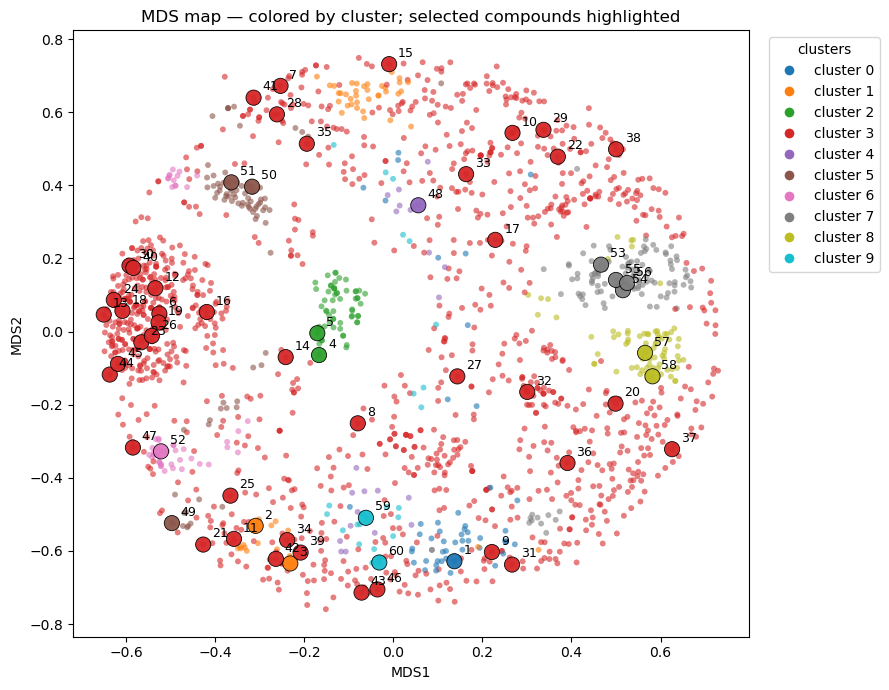


Mapping (label, df_index, smiles, cluster):
(1, 1408, 'COc1ccc(S(=O)(=O)N2CCc3cc(Nc4ncc(C)c(-c5cnn(C(C)C)c5)n4)ccc32)cc1', np.int32(0))
(2, 152, 'C1=CCOCc2cc(ccc2OCCN2CCCCC2)Nc2nccc(n2)-c2cccc(c2)COC1', np.int32(1))
(3, 114, 'CN1C/C=C/COCc2ccc(o2)-c2ccnc(n2)Nc2cccc(c2)C1', np.int32(1))
(4, 1326, 'NC(=O)c1cnc2[nH]ccc2c1NC1CCN(Cc2ccccc2)CC1', np.int32(2))
(5, 1331, 'O=C(NC1CC1)c1cnc2[nH]ccc2c1NC1CCN(Cc2ccccc2)CC1', np.int32(2))
(6, 690, 'OC1CCN(C[C@H]2CC[C@H](c3nnn4cnc5[nH]ccc5c34)CC2)CC1', np.int32(3))
(7, 436, 'CC(C)[C@H](C)n1cc(-c2cc(C3CCOCC3)n(C)n2)c2[nH]nc(N)c2c1=O', np.int32(3))
(8, 903, 'CC(=O)NCC(=O)N1C2CCC1c1cc(Nc3ncc(C(F)(F)F)c(NC4CCC4)n3)ccc12', np.int32(3))
(9, 1293, 'C[C@@H]1[C@@H]2CN(c3nc(Nc4cnn(CCO)c4)ncc3F)C[C@]12NC(=O)[C@H]1C[C@@H]1C#N', np.int32(3))
(10, 1593, 'O=C(Nc1nc2cccc(C3=CC[C@@H](NC(=O)[C@H]4CC4(F)F)CC3)n2n1)C1CC1', np.int32(3))
(11, 1229, 'CCc1cc(O)c(F)cc1-c1cc(NS(=O)(=O)N(C)C)c2cn[nH]c2c1', np.int32(3))
(12, 570, 'FCCNC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1'

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ensure MDS coords exist, otherwise try to recompute from 'dist'
if 'coords' not in globals():
    if 'dist' in globals():
        from sklearn.manifold import MDS
        mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
        coords = mds.fit_transform(dist)
    else:
        raise RuntimeError('No MDS coords or distance matrix available. Run the clustering/MDS cell first.')

# ensure selected_df exists
if 'selected_df' not in globals():
    raise RuntimeError('selected_df not found. Run the selection cell that produces selected_df.')

# ensure cluster_col is known (fallback to available cluster columns)
if 'cluster_col' not in globals():
    for col in ('cluster_fp', 'cluster_tanimoto', 'cluster'):
        if col in df.columns:
            cluster_col = col
            break

# cluster labels for all molecules (aligned with df order used to build fps/coords)
if cluster_col not in df.columns:
    raise RuntimeError(f'Cluster column {cluster_col} not found in df')
cluster_all = df[cluster_col].fillna(-1).astype(int).to_numpy()

# unique clusters present (exclude -1 placeholder)
unique_clusters = np.unique(cluster_all[cluster_all >= 0])
n_clusters = len(unique_clusters)

# choose cmap
cmap_name = 'tab20' if n_clusters > 10 else 'tab10'
cmap = plt.get_cmap(cmap_name)

# map cluster id -> color index (0..N-1)
cluster_to_idx = {c: i for i, c in enumerate(unique_clusters)}
color_idx_all = np.array([cluster_to_idx.get(int(c), -1) for c in cluster_all])

# build RGBA color array for all points (default gray for unknown)
colors_all = np.array([cmap(i % cmap.N) if i >= 0 else (0.8,0.8,0.8,0.6) for i in color_idx_all])

# Map selected SMILES back to original df indices (take first match when duplicates exist)
sel_indices = []
for smi in selected_df['smiles']:
    matches = df.index[df['smiles'] == smi].tolist()
    sel_indices.append(matches[0] if matches else None)

# Filter valid indices and prepare coordinates and colors for selected points
valid_pairs = [(i, int(idx)) for i, idx in enumerate(sel_indices) if idx is not None and 0 <= int(idx) < coords.shape[0]]
if not valid_pairs:
    raise RuntimeError('No valid matches between selected_df and df for plotting.')
valid_df_indices = np.array([idx for _, idx in valid_pairs], dtype=int)
sel_coords = coords[valid_df_indices]
sel_cluster_idx = np.array([cluster_to_idx.get(int(cluster_all[int(idx)]), -1) for idx in valid_df_indices])
sel_colors = np.array([cmap(i % cmap.N) if i >= 0 else (1,0,0,1) for i in sel_cluster_idx])

# Plot: all points colored by cluster, selected points highlighted
plt.figure(figsize=(9,7))
plt.scatter(coords[:,0], coords[:,1], c=colors_all, s=18, alpha=0.6, edgecolors='none')
plt.scatter(sel_coords[:,0], sel_coords[:,1], c=sel_colors, s=120, alpha=0.95, edgecolors='k', linewidths=0.6, label='selected')

# add numeric labels (1..n) to selected points
for num, (x,y) in enumerate(sel_coords, start=1):
    plt.text(x + 0.02, y + 0.02, str(num), fontsize=9)

# legend for clusters (show color patches for each cluster)
legend_elems = []
for c in unique_clusters:
    idx = cluster_to_idx[c]
    legend_elems.append(Line2D([0], [0], marker='o', color='w', label=f'cluster {c}', markerfacecolor=cmap(idx % cmap.N), markersize=8))
plt.legend(handles=legend_elems, bbox_to_anchor=(1.02, 1), loc='upper left', title='clusters')

plt.title('MDS map — colored by cluster; selected compounds highlighted')
plt.xlabel('MDS1'); plt.ylabel('MDS2')
plt.tight_layout()
plt.show()

# Print mapping: number -> df index -> smiles -> cluster
print('\nMapping (label, df_index, smiles, cluster):')
for label_num, df_idx in enumerate(valid_df_indices, start=1):
    smi = df.at[int(df_idx), 'smiles'] if 'smiles' in df.columns else None
    cl = df.at[int(df_idx), cluster_col] if cluster_col in df.columns else None
    print((label_num, int(df_idx), smi, cl))

Could not save image: 'Image' object has no attribute 'save'


/Users/keetane/miniforge3/envs/r4/lib/python3.10/site-packages/rdkit/Chem/Draw/IPythonConsole.py:343: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


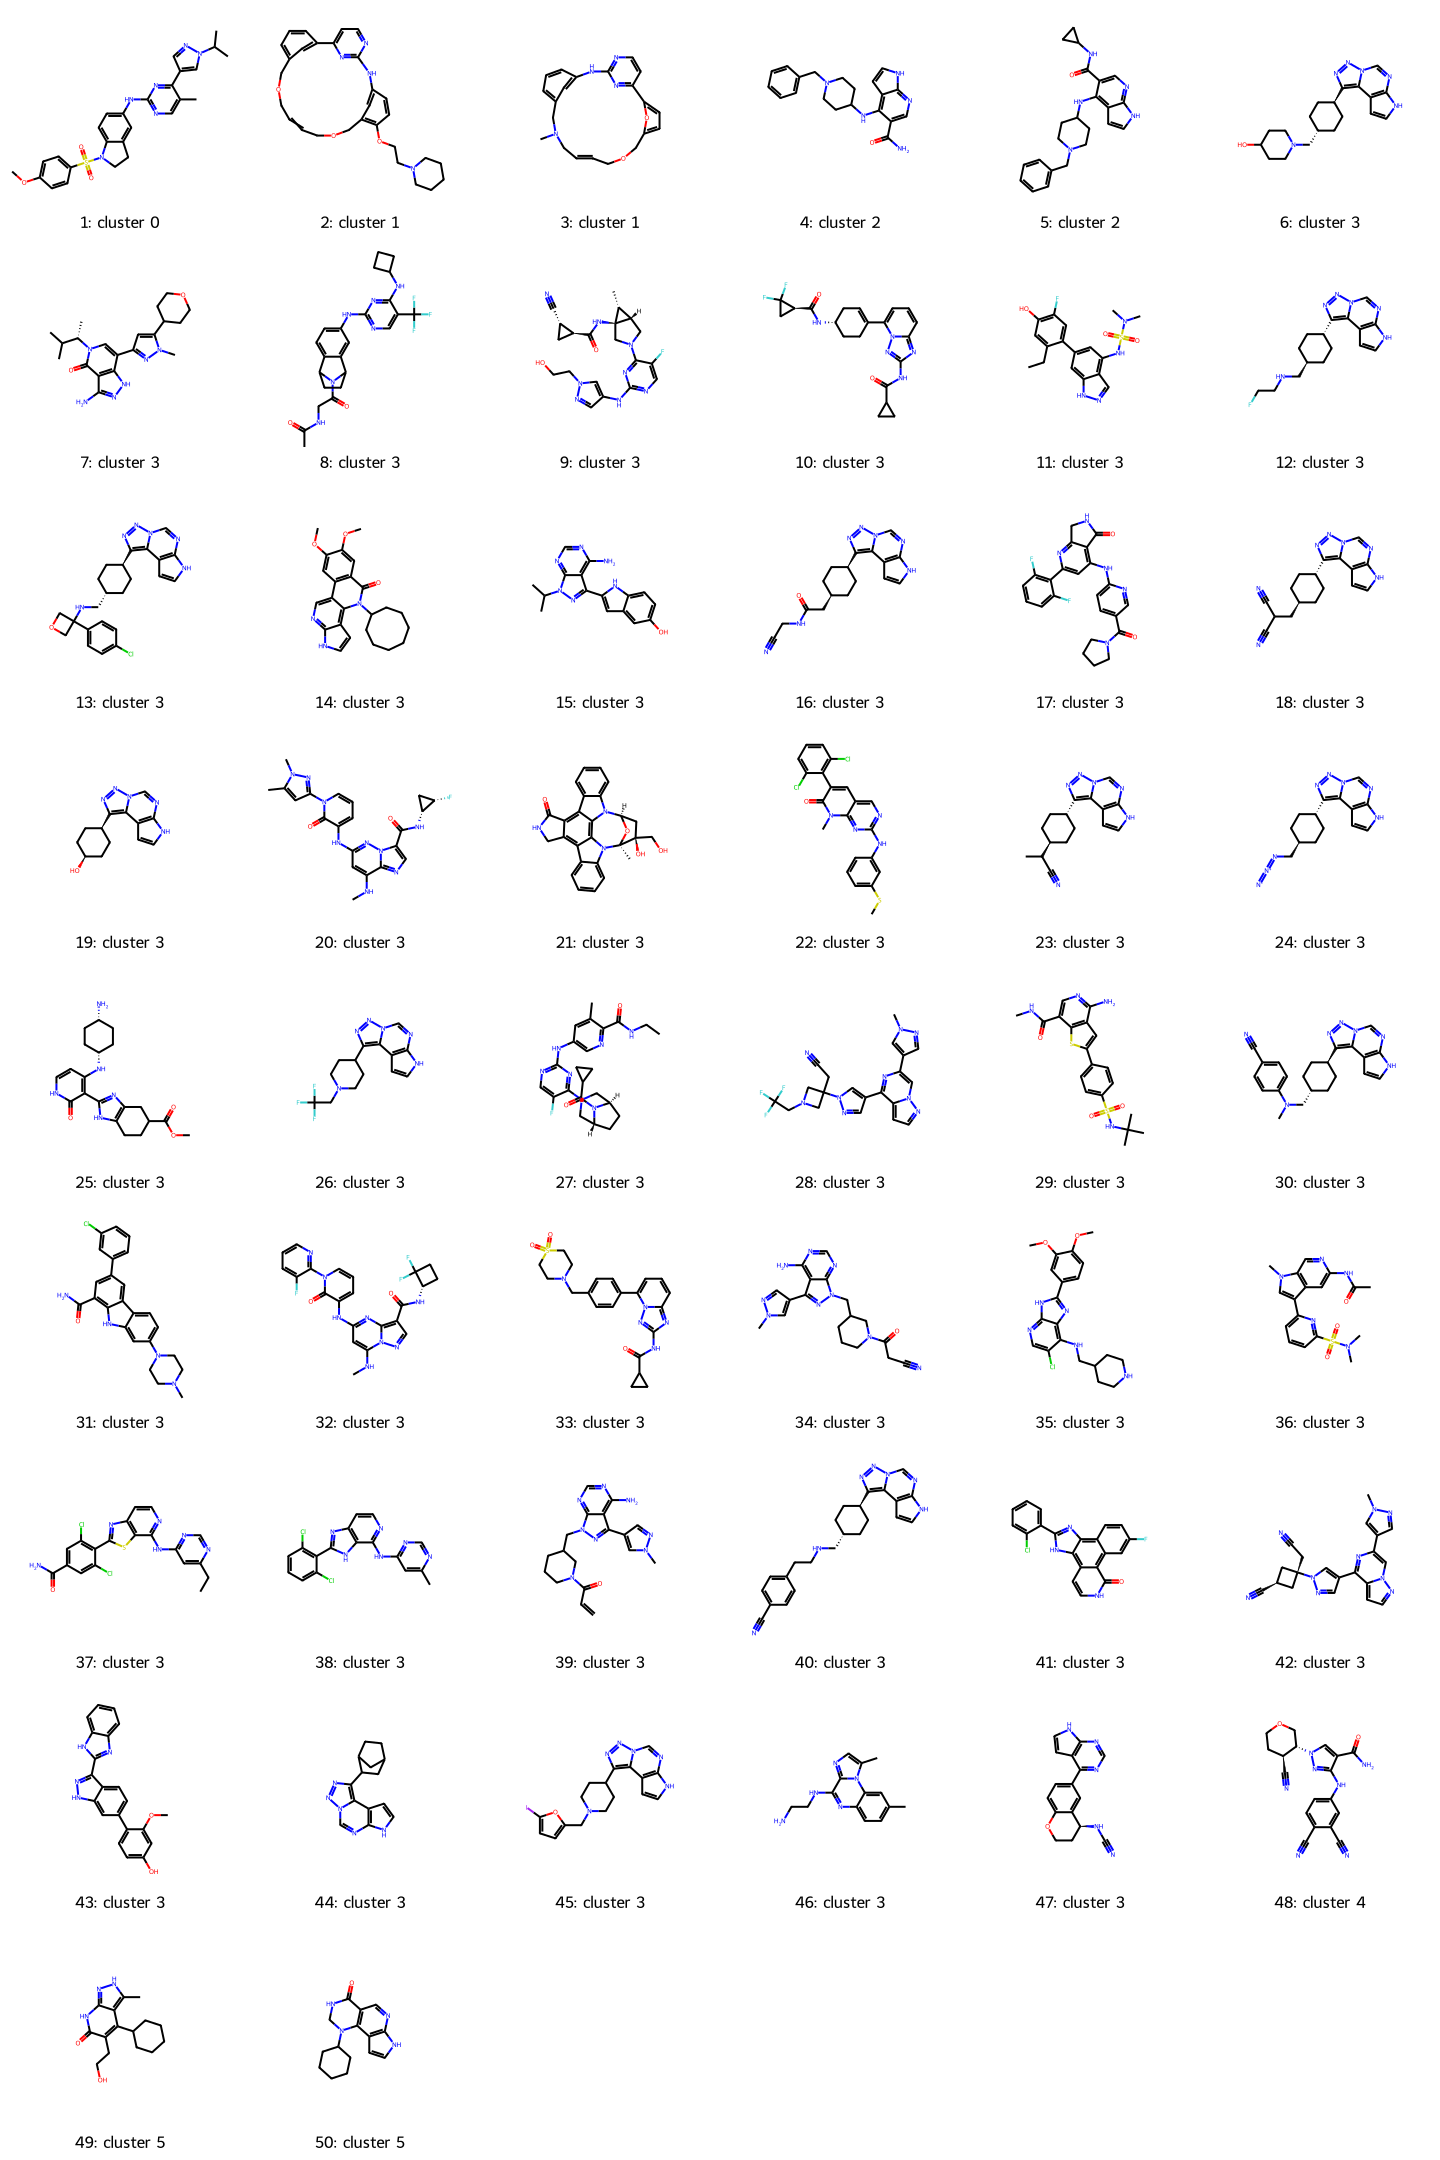


Legend (label, cluster, smiles):
(1, 0, 'COc1ccc(S(=O)(=O)N2CCc3cc(Nc4ncc(C)c(-c5cnn(C(C)C)c5)n4)ccc32)cc1')
(2, 1, 'C1=CCOCc2cc(ccc2OCCN2CCCCC2)Nc2nccc(n2)-c2cccc(c2)COC1')
(3, 1, 'CN1C/C=C/COCc2ccc(o2)-c2ccnc(n2)Nc2cccc(c2)C1')
(4, 2, 'NC(=O)c1cnc2[nH]ccc2c1NC1CCN(Cc2ccccc2)CC1')
(5, 2, 'O=C(NC1CC1)c1cnc2[nH]ccc2c1NC1CCN(Cc2ccccc2)CC1')
(6, 3, 'OC1CCN(C[C@H]2CC[C@H](c3nnn4cnc5[nH]ccc5c34)CC2)CC1')
(7, 3, 'CC(C)[C@H](C)n1cc(-c2cc(C3CCOCC3)n(C)n2)c2[nH]nc(N)c2c1=O')
(8, 3, 'CC(=O)NCC(=O)N1C2CCC1c1cc(Nc3ncc(C(F)(F)F)c(NC4CCC4)n3)ccc12')
(9, 3, 'C[C@@H]1[C@@H]2CN(c3nc(Nc4cnn(CCO)c4)ncc3F)C[C@]12NC(=O)[C@H]1C[C@@H]1C#N')
(10, 3, 'O=C(Nc1nc2cccc(C3=CC[C@@H](NC(=O)[C@H]4CC4(F)F)CC3)n2n1)C1CC1')
(11, 3, 'CCc1cc(O)c(F)cc1-c1cc(NS(=O)(=O)N(C)C)c2cn[nH]c2c1')
(12, 3, 'FCCNC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1')
(13, 3, 'Clc1ccc(C2(NC[C@H]3CC[C@H](c4nnn5cnc6[nH]ccc6c45)CC3)COC2)cc1')
(14, 3, 'COc1cc2c(=O)n(C3CCCCCCC3)c3c4cc[nH]c4ncc3c2cc1OC')
(15, 3, 'CC(C)n1nc(-c2cc3cc(O)ccc3[nH]2)c2c(N)ncn

In [11]:
from rdkit import Chem
from rdkit.Chem import Draw
import pandas as pd
from IPython.display import display

# Ensure selected_df exists
if 'selected_df' not in globals():
    raise RuntimeError('selected_df not found. Run the selection cell first.')

# Ensure cluster_col is set or find fallback
if 'cluster_col' not in globals():
    for col in ('cluster_fp', 'cluster_tanimoto', 'cluster'):
        if col in df.columns:
            cluster_col = col
            break

# Prepare molecules and legends
mols = []
legends = []
for i, row in selected_df.reset_index().iterrows():
    mol = row.get('ROMol') if 'ROMol' in row else None
    if mol is None and 'smiles' in row and pd.notnull(row['smiles']):
        try:
            mol = Chem.MolFromSmiles(row['smiles'])
        except Exception:
            mol = None
    if mol is None:
        # skip entries that cannot be parsed
        continue
    mols.append(mol)
    cl = row.get(cluster_col) if cluster_col in row else (row.get(cluster_col) if cluster_col in selected_df.columns else None)
    cl_str = str(int(cl)) if (pd.notnull(cl) and str(cl).lstrip('-').isdigit()) else 'NA'
    legends.append(f"{i+1}: cluster {cl_str}")

if not mols:
    raise RuntimeError('No valid molecules to draw')

# layout parameters
per_row = 6
subimg_sz = (240, 240)

# Create grid image with legends and save/display
img = Draw.MolsToGridImage(mols, molsPerRow=per_row, subImgSize=subimg_sz, legends=legends, useSVG=False)
try:
    img.save('./selected_60_grid.png')
    print('Wrote ./selected_60_grid.png')
except Exception as e:
    print('Could not save image:', e)

# display inline
display(img)

# Print short legend table (label -> cluster -> smiles)
print('\nLegend (label, cluster, smiles):')
for i, row in selected_df.reset_index().iterrows():
    if i >= len(legends):
        break
    cl = row.get(cluster_col) if cluster_col in row else (row.get(cluster_col) if cluster_col in selected_df.columns else None)
    smi = row.get('smiles') if 'smiles' in row else None
    print((i+1, cl if pd.notnull(cl) else 'NA', smi))